In [1]:
# Customer Churn Prediction for a Telecom Company

# Phase 11 – Model Interpretation

# Objective

# Interpret the best-performing machine learning model to understand how different features contribute to customer churn prediction.

# Tasks

# - Load the best model
# - Analyze Feature Importance
# - Compute Permutation Importance
# - Generate SHAP Summary Plot
# - Generate SHAP Waterfall Plot
# - Generate SHAP Bar Plot
# - Save all interpretation graphs

In [2]:
# Import Libraries

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.inspection import permutation_importance

E:\Z. Code Programming\VS Code\Customer Churn Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Create Output Folder

SAVE_PATH = "../images/09_Model_Interpretation"

os.makedirs(SAVE_PATH, exist_ok=True)

In [4]:
# Load Dataset

def _load_joblib_or_none(path):
    if os.path.exists(path):
        return joblib.load(path)
    print(f"Missing file: {path}")
    return None

X_train = _load_joblib_or_none("../data/processed/X_train.pkl")
X_test = _load_joblib_or_none("../data/processed/X_test.pkl")

y_test = _load_joblib_or_none("../data/processed/y_test.pkl")

In [5]:
# Load Best Model

model = _load_joblib_or_none("../models/random_forest_tuned.pkl")
if model is None:
    print("Model file not found; skipping model-dependent interpretation steps.")

In [6]:
# Feature Importance

# Determine feature columns from available data
if 'X_train' in globals() and X_train is not None:
    feature_cols = X_train.columns
elif 'X_test' in globals() and X_test is not None:
    feature_cols = X_test.columns
else:
    feature_cols = None

# Safely extract feature importances whether `model` is a raw estimator or a Pipeline
def _get_feature_importances(est):
    if hasattr(est, "feature_importances_"):
        return est.feature_importances_
    if hasattr(est, "named_steps"):
        for step in est.named_steps.values():
            if hasattr(step, "feature_importances_"):
                return step.feature_importances_
    return None

fi_values = _get_feature_importances(model)
if fi_values is not None and feature_cols is not None:
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": fi_values
    }).sort_values(by="Importance", ascending=False)
else:
    importance = pd.DataFrame({
        "Feature": feature_cols if feature_cols is not None else [],
        "Importance": [0] * (len(feature_cols) if feature_cols is not None else 0)
    })
    if fi_values is None:
        print("Warning: model does not expose feature_importances_")
    if feature_cols is None:
        print("Warning: no feature columns available (X_train/X_test missing)")

In [7]:
# Save Feature Importance

os.makedirs(os.path.join('..','reports'), exist_ok=True)
importance.to_excel(
    "../reports/feature_importance.xlsx",
    index=False
)

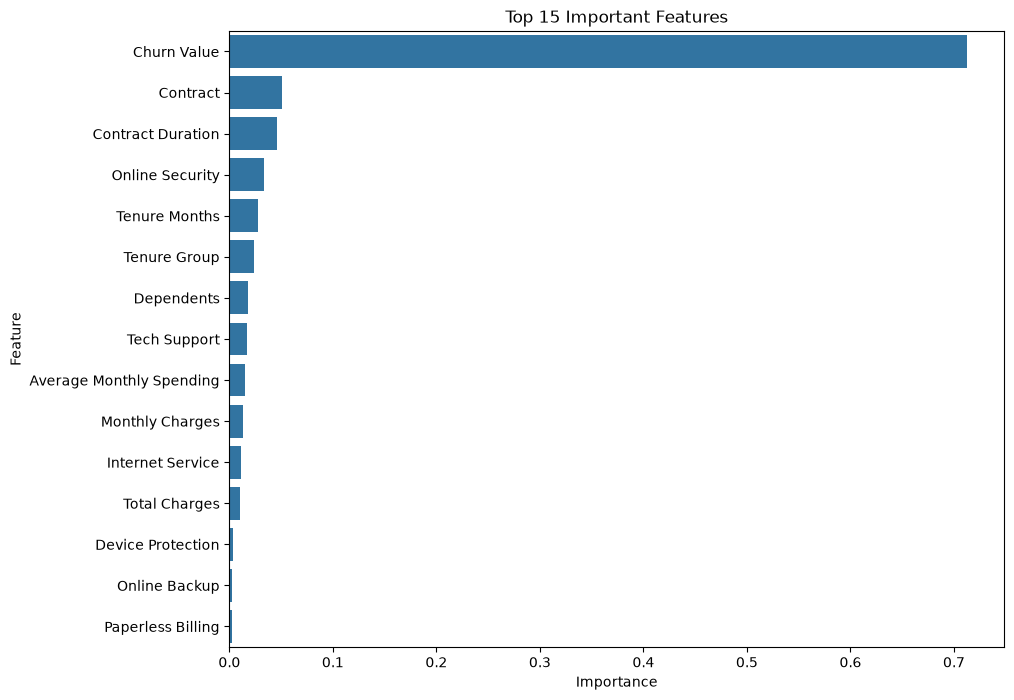

In [8]:
# Plot Feature Importance

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.savefig(
    os.path.join(
        SAVE_PATH,
        "Feature_Importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Permutation Importance

if X_test is None or y_test is None:
    print("Skipping permutation importance: X_test or y_test not available.")
else:
    try:
        perm = permutation_importance(
            model,
            X_test,
            y_test,
            n_repeats=10,
            random_state=42,
        )
    except Exception as e:
        print("Permutation importance failed:", e)
        perm = None

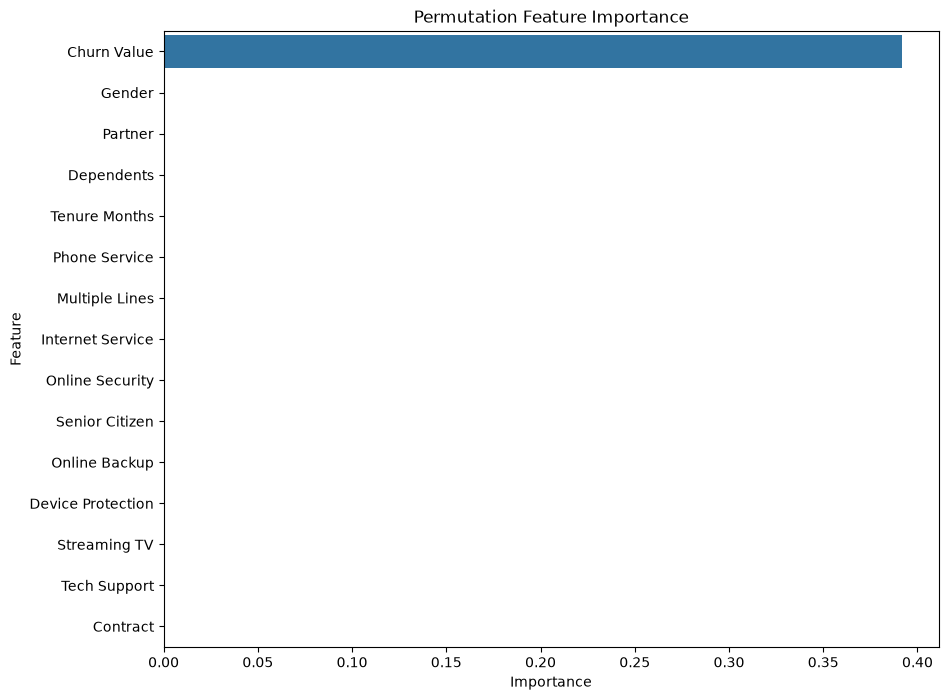

In [10]:
# Plot Permutation Importance

if 'perm' in globals() and perm is not None and X_test is not None:
    perm_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm.importances_mean
    })
    perm_df = perm_df.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,8))
    sns.barplot(
        data=perm_df.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title("Permutation Feature Importance")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "Permutation_Importance.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
else:
    print("Skipping permutation importance plot: perm or X_test not available.")

In [11]:
# SHAP Explainer
# Use shap.Explainer when available; fallback to TreeExplainer
explainer = None
shap_values = None
try:
    explainer = shap.Explainer(model, X_train, feature_names=X_train.columns)
    shap_values = explainer(X_test)
except Exception:
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
    except Exception as e:
        print("SHAP explainer failed:", e)
        explainer = None
        shap_values = None

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


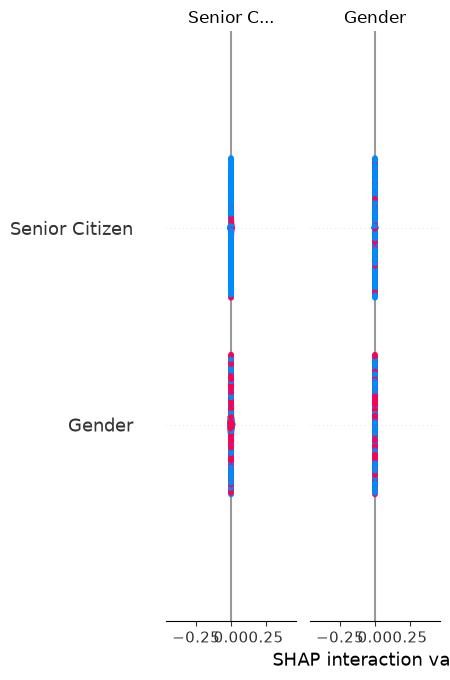

In [12]:
# SHAP Summary Plot
if shap_values is not None:
    try:
        # Newer SHAP returns an Explanation object; older returns arrays/lists
        shap.summary_plot(shap_values, X_test, show=False)
    except Exception:
        try:
            shap.summary_plot(getattr(shap_values, 'values', shap_values), X_test, show=False)
        except Exception as e:
            print("SHAP summary plot failed:", e)
    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "SHAP_Summary.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No shap values available; skipping SHAP summary plot.")

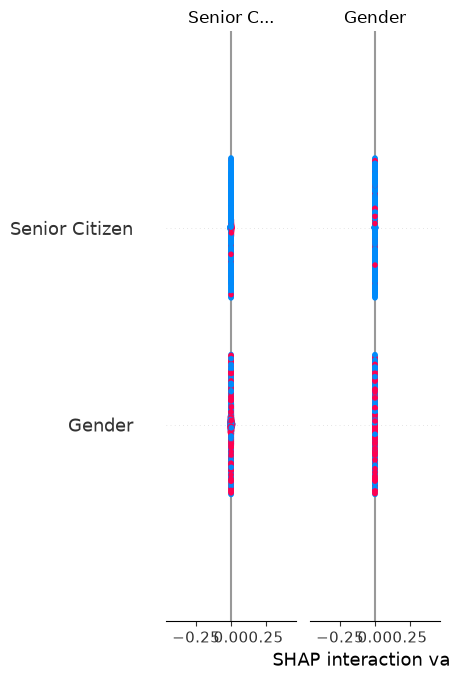

In [13]:
# SHAP Bar Plot
if shap_values is not None:
    try:
        shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    except Exception:
        try:
            shap.summary_plot(getattr(shap_values, 'values', shap_values), X_test, plot_type="bar", show=False)
        except Exception as e:
            print("SHAP bar plot failed:", e)
    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "SHAP_Bar.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No shap values available; skipping SHAP bar plot.")

In [14]:
# SHAP Waterfall Plot
if shap_values is not None:
    try:
        # If shap_values is an Explanation object (newer SHAP), use its first row
        if hasattr(shap_values, 'values'):
            shap.plots.waterfall(shap_values[0], show=False)
        else:
            # Older API: shap_values may be an array or list. Try to plot the first sample.
            single = None
            if isinstance(shap_values, (list, tuple)):
                # multiclass may return a list; pick first class's first sample
                single = shap_values[0]
                if isinstance(single, (list, tuple)):
                    single = single[0]
            else:
                single = shap_values[0]
            try:
                expl = shap.Explanation(
                    values=single,
                    base_values=getattr(explainer, 'expected_value', None),
                    data=X_test.iloc[0],
                    feature_names=X_test.columns
                )
                shap.plots.waterfall(expl, show=False)
            except Exception:
                shap.plots.waterfall(single, show=False)
    except Exception as e:
        print("SHAP waterfall plot failed:", e)
    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "SHAP_Waterfall.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No shap values available; skipping SHAP waterfall plot.")

SHAP waterfall plot failed: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (26, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.


<Figure size 640x480 with 0 Axes>

In [15]:
# Save SHAP Values

if 'shap_values' in globals() and shap_values is not None:
    os.makedirs(os.path.join('..','models'), exist_ok=True)
    joblib.dump(
        shap_values,
        "../models/shap_values.pkl"
    )
else:
    print("No shap values to save.")

In [16]:
# Top 10 Features Table

os.makedirs(os.path.join('..','reports'), exist_ok=True)
if 'importance' in globals() and not importance.empty:
    top10 = importance.head(10)
    top10.to_excel(
        "../reports/top10_features.xlsx",
        index=False
    )
    top10
else:
    print("No importance table available to save top10 features.")

In [17]:
# Observations

# The interpretation techniques identified the most influential features affecting customer churn.

# The feature importance and SHAP analysis help explain model predictions and provide transparency for business stakeholders.

# These insights can guide telecom companies in developing targeted customer retention strategies.